In [1]:
#Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

ROOT          = Path('..').resolve()
RAW_DIR       = ROOT / 'data' / 'raw' / 'ieee-fraud-detection'
PROCESSED_DIR = ROOT / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_TXN = RAW_DIR / 'train_transaction.csv'
TRAIN_ID  = RAW_DIR / 'train_identity.csv'

# Sanity check
assert TRAIN_TXN.exists(), f"Missing: {TRAIN_TXN}"
assert TRAIN_ID.exists(),  f"Missing: {TRAIN_ID}"
print("✅ All files confirmed.")

✅ All files confirmed.


In [2]:
#Cell 2 : Load Data
txn = pd.read_csv(TRAIN_TXN)
idn = pd.read_csv(TRAIN_ID)

print(f"Transactions : {txn.shape[0]:,} rows × {txn.shape[1]} cols")
print(f"Identity     : {idn.shape[0]:,} rows × {idn.shape[1]} cols")

Transactions : 590,540 rows × 394 cols
Identity     : 144,233 rows × 41 cols


In [ ]:
#Cell 3 : Merge Data
df = pd.merge(txn, idn, how='left', on='TransactionID')

print(f"Merged shape : {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"Identity match rate: {idn.shape[0] / txn.shape[0] * 100:.1f}% of transactions have identity data")


Merged shape : 590,540 rows × 434 cols
Identity match rate: 24.4% of transactions have identity data


Not Fraud : 569,877  (96.50%)
Fraud     : 20,663  (3.50%)

scale_pos_weight estimate: 27.58


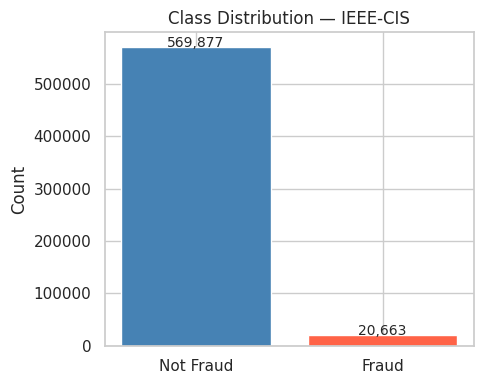

In [4]:
#Cell 5 : Fraud Rate
fraud_counts = df['isFraud'].value_counts()
fraud_rate   = df['isFraud'].mean() * 100

print(f"Not Fraud : {fraud_counts[0]:,}  ({100 - fraud_rate:.2f}%)")
print(f"Fraud     : {fraud_counts[1]:,}  ({fraud_rate:.2f}%)")
print(f"\nscale_pos_weight estimate: {fraud_counts[0] / fraud_counts[1]:.2f}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Not Fraud', 'Fraud'], fraud_counts.values, color=['steelblue', 'tomato'])
ax.set_title('Class Distribution — IEEE-CIS')
ax.set_ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'eda_class_distribution.png', dpi=120)
plt.show()


=== Columns with >50% nulls ===
id_24           99.1962
id_25           99.1310
id_07           99.1271
id_08           99.1271
id_21           99.1264
id_26           99.1257
id_27           99.1247
id_23           99.1247
id_22           99.1247
dist2           93.6284
D7              93.4099
id_18           92.3607
D13             89.5093
D14             89.4695
D12             89.0410
id_04           88.7689
id_03           88.7689
D6              87.6068
id_33           87.5895
id_09           87.3123
D8              87.3123
id_10           87.3123
D9              87.3123
id_30           86.8654
id_32           86.8619
id_34           86.8248
id_14           86.4456
V138            86.1237
V139            86.1237
V148            86.1237
V154            86.1237
V162            86.1237
V141            86.1237
V157            86.1237
V146            86.1237
V163            86.1237
V155            86.1237
V142            86.1237
V161            86.1237
V158            86.1237
V156    

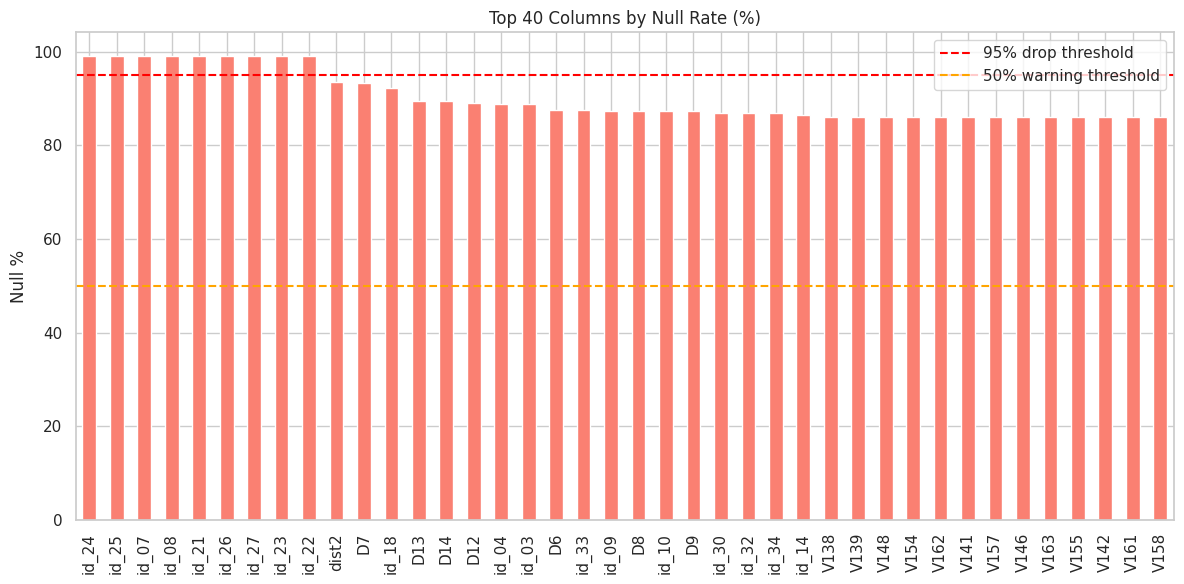

In [5]:
#Cell 5 : Null Rate Analysis
null_rates = (df.isnull().mean() * 100).sort_values(ascending=False)

print("=== Columns with >50% nulls ===")
print(null_rates[null_rates > 50].to_string())
print(f"\nTotal columns >50% null : {(null_rates > 50).sum()}")
print(f"Total columns >95% null : {(null_rates > 95).sum()} → will be dropped")

# Plot top 40 null columns
top_null = null_rates.head(40)
fig, ax = plt.subplots(figsize=(12, 6))
top_null.plot(kind='bar', ax=ax, color='salmon')
ax.axhline(95, color='red',    linestyle='--', label='95% drop threshold')
ax.axhline(50, color='orange', linestyle='--', label='50% warning threshold')
ax.set_title('Top 40 Columns by Null Rate (%)')
ax.set_ylabel('Null %')
ax.legend()
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'eda_null_rates.png', dpi=120)
plt.show()


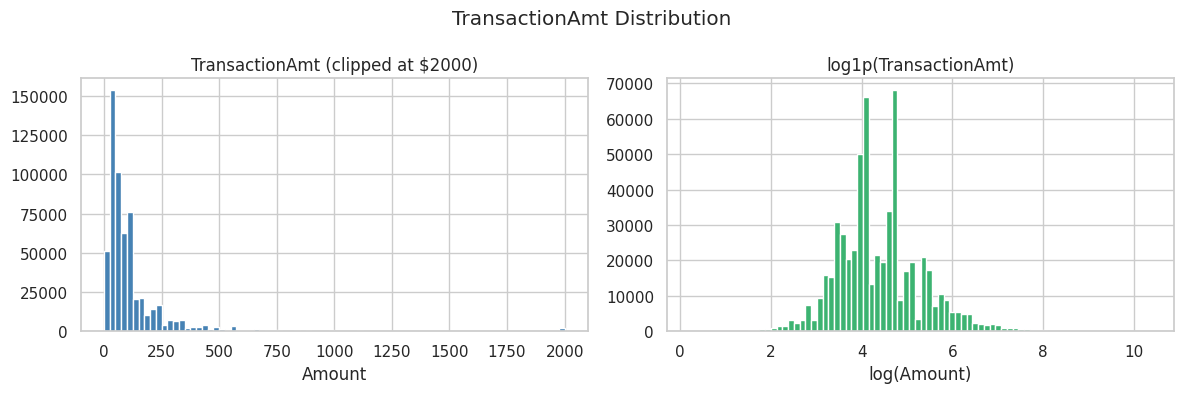

count   590540.0000
mean       135.0272
std        239.1625
min          0.2510
25%         43.3210
50%         68.7690
75%        125.0000
max      31937.3910
Name: TransactionAmt, dtype: float64


In [6]:
#Cell 6 : TransactionAmt Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw
axes[0].hist(df['TransactionAmt'].clip(upper=2000), bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('TransactionAmt (clipped at $2000)')
axes[0].set_xlabel('Amount')

# Log-transformed
axes[1].hist(np.log1p(df['TransactionAmt']), bins=80, color='mediumseagreen', edgecolor='white')
axes[1].set_title('log1p(TransactionAmt)')
axes[1].set_xlabel('log(Amount)')

plt.suptitle('TransactionAmt Distribution')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'eda_amount_distribution.png', dpi=120)
plt.show()

print(df['TransactionAmt'].describe())


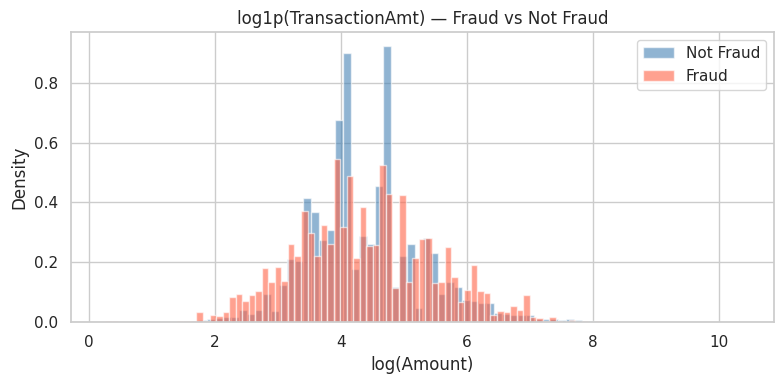

In [7]:
#Cell 7 : Amount by Fraud Label
fig, ax = plt.subplots(figsize=(8, 4))
for label, color in zip([0, 1], ['steelblue', 'tomato']):
    subset = np.log1p(df[df['isFraud'] == label]['TransactionAmt'])
    ax.hist(subset, bins=80, alpha=0.6, color=color,
            label='Fraud' if label else 'Not Fraud', density=True)
ax.set_title('log1p(TransactionAmt) — Fraud vs Not Fraud')
ax.set_xlabel('log(Amount)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'eda_amount_by_fraud.png', dpi=120)
plt.show()


/tmp/ipykernel_10192/3926138208.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['hour']        = (df['TransactionDT'] // 3600) % 24
/tmp/ipykernel_10192/3926138208.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['day_of_week'] = (df['TransactionDT'] // (3600 * 24)) % 7


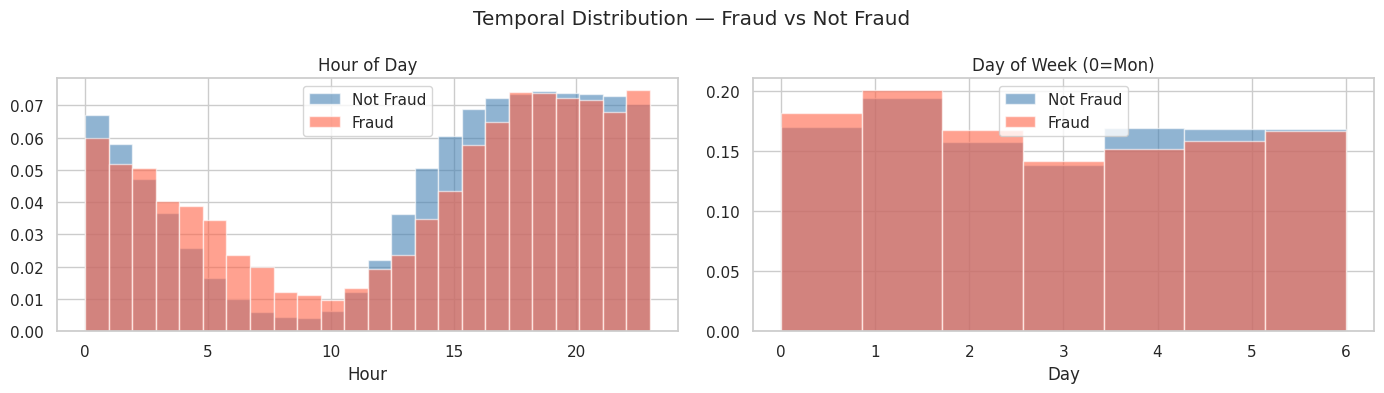

In [8]:
#Cell 8 : Time Feature (TransactionDT)
df['hour']        = (df['TransactionDT'] // 3600) % 24
df['day_of_week'] = (df['TransactionDT'] // (3600 * 24)) % 7

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label, color in zip([0, 1], ['steelblue', 'tomato']):
    subset = df[df['isFraud'] == label]
    lname  = 'Fraud' if label else 'Not Fraud'
    axes[0].hist(subset['hour'],        bins=24, alpha=0.6, color=color, label=lname, density=True)
    axes[1].hist(subset['day_of_week'], bins=7,  alpha=0.6, color=color, label=lname, density=True)

axes[0].set_title('Hour of Day')
axes[0].set_xlabel('Hour')
axes[1].set_title('Day of Week (0=Mon)')
axes[1].set_xlabel('Day')
for ax in axes:
    ax.legend()
plt.suptitle('Temporal Distribution — Fraud vs Not Fraud')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'eda_temporal.png', dpi=120)
plt.show()


In [9]:
#Cell 9 : UID Building Block Columns
uid_cols = ['card1', 'card2', 'addr1', 'P_emaildomain']

print("=== Unique value counts (UID building blocks) ===")
for col in uid_cols:
    n_unique = df[col].nunique()
    null_pct = df[col].isnull().mean() * 100
    print(f"  {col:<20} unique={n_unique:>6,}   null={null_pct:.1f}%")

# Preview dominant email domains
print("\n=== Top 10 P_emaildomain values ===")
print(df['P_emaildomain'].value_counts().head(10).to_string())


=== Unique value counts (UID building blocks) ===
  card1                unique=13,553   null=0.0%
  card2                unique=   500   null=1.5%
  addr1                unique=   332   null=11.1%
  P_emaildomain        unique=    59   null=16.0%

=== Top 10 P_emaildomain values ===
P_emaildomain
gmail.com        228355
yahoo.com        100934
hotmail.com       45250
anonymous.com     36998
aol.com           28289
comcast.net        7888
icloud.com         6267
outlook.com        5096
msn.com            4092
att.net            4033


In [10]:
# Cell 10 : Identity Signal Columns (Null-as-Signal Preview)
identity_signal_cols = ['id_30', 'id_31', 'id_33', 'id_36', 'DeviceType', 'DeviceInfo']

print("=== Identity column null rates by fraud label ===")
result = []
for col in identity_signal_cols:
    null_fraud     = df[df['isFraud'] == 1][col].isnull().mean() * 100
    null_not_fraud = df[df['isFraud'] == 0][col].isnull().mean() * 100
    result.append({'column': col, 'null_if_fraud': null_fraud, 'null_if_not_fraud': null_not_fraud})

null_df = pd.DataFrame(result).set_index('column')
print(null_df.round(1).to_string())

# A big gap between null_if_fraud and null_if_not_fraud = strong signal
null_df['gap'] = (null_df['null_if_fraud'] - null_df['null_if_not_fraud']).abs()
print(f"\nLargest gap: {null_df['gap'].idxmax()} ({null_df['gap'].max():.1f}pp)")


=== Identity column null rates by fraud label ===
            null_if_fraud  null_if_not_fraud
column                                      
id_30             83.3000            87.0000
id_31             45.9000            77.3000
id_33             83.7000            87.7000
id_36             45.7000            77.2000
DeviceType        45.7000            77.3000
DeviceInfo        58.3000            80.7000

Largest gap: id_36 (31.5pp)


In [11]:
#Cell 11 : Round Amount Check (Card Testing Signal)
df['amt_decimal']     = df['TransactionAmt'] - np.floor(df['TransactionAmt'])
df['is_round_amount'] = (df['amt_decimal'] == 0).astype(int)

round_fraud     = df[df['isFraud'] == 1]['is_round_amount'].mean() * 100
round_not_fraud = df[df['isFraud'] == 0]['is_round_amount'].mean() * 100

print(f"Round amount rate — Fraud    : {round_fraud:.2f}%")
print(f"Round amount rate — Not Fraud: {round_not_fraud:.2f}%")
print(f"Ratio: {round_fraud / round_not_fraud:.2f}× more common in fraud")


/tmp/ipykernel_10192/2086219883.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['amt_decimal']     = df['TransactionAmt'] - np.floor(df['TransactionAmt'])
/tmp/ipykernel_10192/2086219883.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['is_round_amount'] = (df['amt_decimal'] == 0).astype(int)


Round amount rate — Fraud    : 52.66%
Round amount rate — Not Fraud: 51.61%
Ratio: 1.02× more common in fraud
